# Batch-cut shot gathers at the observed apex

This notebook picks the apex for every shot in `active_time_window_shots.csv` and writes a cut DASCore patch.


1. Around the catalog shot time, on channels near the predicted water-arrival apex. The observed apex is the channel whose smoothed absolute-amplitude peak is earliest.
2. The saved gather starts `PRE_APEX_S` before that observed apex time and ends `POST_APEX_S` after it. Along the cable it keeps `obs_s ± APERTURE_HALFWIDTH_M`.

The pilot cell processes one selected recording. Set `RUN_BATCH = True` to write the rest.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

import dascore as dc
from dascore.units import Hz
from pyproj import Transformer, datadir

In [ ]:
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()  # repo root
EXPERIMENT_ROOT = Path('/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025')  # root of the DAS folder
ACTIVE_DIR = EXPERIMENT_ROOT / 'Data' / 'Sintela_Active'  # one-minute raw recordings
METADATA = ROOT / 'Preparation' / 'Codes' / 'metadata'  # folder with the shot catalog and cable geometry
SHOTS_PATH = METADATA / 'active_time_window_shots.csv'  # shot time matched to each file
GEOMETRY_PATH = METADATA / 'Aqualink_Geometry_withdepth.csv'  # cable East/North/depth
OUT_DIR = EXPERIMENT_ROOT / 'Products' / 'shot_gathers'  # written shot_<id>.h5 files

# Search window: find the observed apex on the direct arrival.
WATER_VELOCITY_M_S = 1500.0          # water speed for the predicted apex
APEX_SEARCH_HALFWIDTH_M = 8_000.0    # channels kept around the predicted apex
OBS_WINDOW_S = (0., 8.0)            # seconds after the catalog shot time
SMOOTH_CHANNELS = 21                 # along-cable smooth of peak times
CABLE_MAX_DISTANCE_M = 70_000.0      # farthest cable distance used
DECIMATE_FACTOR = 5                  # time decimation before the pick
FMIN_HZ = 10.0                        # high-pass corner before the pick

# Output window, measured from the observed apex time.
PRE_APEX_S = 0.5                     # lead time kept before the apex
POST_APEX_S = 6.0                    # time kept after the apex
APERTURE_HALFWIDTH_M = 4_000.0       # cable distance kept on each side of the apex
NEIGHBOR_GUARD_S = 0.5               # stop this long before the next shot
MAX_APEX_SHIFT_M = 1_000.0           # reject picks farther than this from the prediction

# Pilot recording and shots.
PILOT_RECORDING = 'decimator_2025-10-11_03.28.30_UTC_073689.raw'  # file to test
PILOT_SHOT_IDS = [3024, 3025, 3026, 3027, 3028]                   # shots inside that file
# PILOT_RECORDING = 'decimator_2025-10-11_03.32.30_UTC_073693.raw'  # file to test
# PILOT_SHOT_IDS = [3058, 3059, 3060, 3061, 3062]                   # shots inside that file

WRITE_PILOT = True    # write the pilot gathers
RUN_BATCH = False     # True processes every catalog shot
OVERWRITE = False     # False leaves an existing shot_<id>.h5 unchanged

print('Shots catalog:', SHOTS_PATH.exists())
print('Active dir:', ACTIVE_DIR.exists())
print('Output:', OUT_DIR)

Shots catalog: True
Active dir: True
Output: /Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/Products/shot_gathers


In [5]:
# Load the shot catalog and the cable geometry used to predict the apex.
# Shot times locate each recording; East/North/depth give the water-path distance.
shots = pd.read_csv(SHOTS_PATH)
shots['shot_datetime_utc'] = pd.to_datetime(shots['shot_datetime_utc'], utc=True)
shots['recording_start_utc'] = pd.to_datetime(shots['recording_start_utc'], utc=True)
shots = shots.sort_values(['recording_start_utc', 'shot_datetime_utc']).reset_index(drop=True)

geometry = pd.read_csv(GEOMETRY_PATH).sort_values('distance')
geometry = geometry.loc[geometry['distance'] <= CABLE_MAX_DISTANCE_M].copy()
geometry['depth_m'] = geometry['Depth_m'].where(geometry['Depth_m'] != -9999.0)
valid_depth = geometry['depth_m'].notna()
geometry_s = geometry['distance'].to_numpy(dtype=float)
geometry_xyz = np.column_stack([
    geometry['East'].to_numpy(dtype=float),
    geometry['North'].to_numpy(dtype=float),
    np.interp(
        geometry_s,
        geometry.loc[valid_depth, 'distance'].to_numpy(dtype=float),
        geometry.loc[valid_depth, 'depth_m'].to_numpy(dtype=float),
    ),
])

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:2193', always_xy=True)
print(f'{len(shots)} shots in {shots["recording_filename"].nunique()} recordings')
print(f'Geometry: {geometry_s.min():.0f}–{geometry_s.max():.0f} m, n={len(geometry_s)}')

692 shots in 81 recordings
Geometry: 0–69989 m, n=5486


In [6]:
# Helper functions

# Convert to DASCore units
def _ns(seconds):
    return np.timedelta64(int(float(seconds) * 1e9), 'ns')

# Convert to DASCore units
def _as_utc_ns(timestamp):
    return np.datetime64(pd.Timestamp(timestamp).to_datetime64())

# Predict the apex
def predicted_apex_s(longitude, latitude):
    east, north = transformer.transform(float(longitude), float(latitude))
    travel_s = np.linalg.norm(geometry_xyz - np.array([east, north, 0.0]), axis=1) / WATER_VELOCITY_M_S
    idx = int(np.argmin(travel_s))
    return float(geometry_s[idx]), float(travel_s[idx])

# Preprocess the gather
def preprocess(patch, decimate=DECIMATE_FACTOR, fmin=FMIN_HZ):
    return (
        patch
        .set_units(distance='m', time='s')
        .decimate(time=decimate)
        .detrend('time')
        .taper(time=0.005)
        .pass_filter(time=(fmin * Hz, ...))
    )

def find_observed_apex(data, time_coord, dist, shot_time, pred_s):
    data = np.asarray(data, dtype=float)
    dist = np.asarray(dist, dtype=float)
    time_coord = np.asarray(time_coord)
    if data.shape[0] == len(dist) and data.shape[1] != len(dist):
        data = data.T
    if data.shape != (len(time_coord), len(dist)):
        raise ValueError(f'data shape {data.shape} does not match time/distance')

    time_s = (time_coord - time_coord[0]) / np.timedelta64(1, 's')
    shot_t0 = _as_utc_ns(shot_time)
    shot_offset_s = (shot_t0 - time_coord[0]) / np.timedelta64(1, 's')
    t_mask = (
        (time_s >= shot_offset_s + OBS_WINDOW_S[0])
        & (time_s <= shot_offset_s + OBS_WINDOW_S[1])
    )
    d_mask = np.abs(dist - float(pred_s)) <= APEX_SEARCH_HALFWIDTH_M
    if int(t_mask.sum()) < 5 or int(d_mask.sum()) < 5:
        return None

    window = np.abs(data[np.ix_(t_mask, d_mask)])
    peak_idx = np.argmax(window, axis=0)
    peak_delay_s = time_s[t_mask][peak_idx] - shot_offset_s
    n_sm = min(int(SMOOTH_CHANNELS), int(peak_delay_s.size))
    if n_sm % 2 == 0:
        n_sm -= 1
    if n_sm >= 3:
        peak_delay_s = uniform_filter1d(peak_delay_s.astype(float), size=n_sm, mode='nearest')
    obs_i = int(np.argmin(peak_delay_s))
    return float(dist[d_mask][obs_i]), float(peak_delay_s[obs_i])

def next_shot_time(shot_row):
    later = shots.loc[shots['shot_datetime_utc'] > shot_row.shot_datetime_utc, 'shot_datetime_utc']
    if later.empty:
        return None
    return later.iloc[0]

def cut_shot_gather(spool, shot_row, *, write=False):
    shot_id = int(shot_row.shot_id)
    shot_time = pd.Timestamp(shot_row.shot_datetime_utc)
    shot_t0 = _as_utc_ns(shot_time)
    pred_s, pred_tt = predicted_apex_s(shot_row.longitude, shot_row.latitude)
    out_path = OUT_DIR / f'shot_{shot_id:05d}.h5'

    record = {
        'shot_id': shot_id,
        'recording_filename': shot_row.recording_filename,
        'shot_datetime_utc': shot_time.isoformat(),
        'pred_apex_s_m': pred_s,
        'pred_min_tt_s': pred_tt,
        'obs_apex_s_m': np.nan,
        'obs_min_tt_s': np.nan,
        'delta_s_m': np.nan,
        't_cut0_utc': '',
        't_cut1_utc': '',
        's_cut0_m': np.nan,
        's_cut1_m': np.nan,
        'status': 'pending',
        'output_path': str(out_path),
    }

    nxt = next_shot_time(shot_row)
    dt_next = np.inf if nxt is None else (pd.Timestamp(nxt) - shot_time).total_seconds()
    t_ext0 = shot_t0 + _ns(min(0.0, OBS_WINDOW_S[0] - PRE_APEX_S) - 0.25)
    t_ext1 = shot_t0 + _ns(min(OBS_WINDOW_S[1] + POST_APEX_S, dt_next - NEIGHBOR_GUARD_S))
    if t_ext1 <= t_ext0:
        record['status'] = 'no_time_window'
        return record, None

    s_ext0 = max(0.0, pred_s - APEX_SEARCH_HALFWIDTH_M - APERTURE_HALFWIDTH_M)
    s_ext1 = min(CABLE_MAX_DISTANCE_M, pred_s + APEX_SEARCH_HALFWIDTH_M + APERTURE_HALFWIDTH_M)
    patches = list(spool.select(time=(t_ext0, t_ext1), distance=(s_ext0, s_ext1)).chunk(time=None))
    if not patches:
        record['status'] = 'no_data'
        return record, None

    proc = preprocess(patches[0])
    dist = np.asarray(proc.get_coord('distance').values, dtype=float)
    time_coord = np.asarray(proc.get_coord('time').values)
    picked = find_observed_apex(proc.data, time_coord, dist, shot_time, pred_s)
    if picked is None:
        record['status'] = 'apex_not_found'
        return record, None

    obs_s, obs_tt = picked
    record['obs_apex_s_m'] = obs_s
    record['obs_min_tt_s'] = obs_tt
    record['delta_s_m'] = obs_s - pred_s
    if abs(obs_s - pred_s) > MAX_APEX_SHIFT_M:
        record['status'] = 'apex_shift'
        return record, None

    apex_time = shot_t0 + _ns(obs_tt)
    t_cut0 = apex_time - _ns(PRE_APEX_S)
    t_cut1 = apex_time + _ns(POST_APEX_S)
    if np.isfinite(dt_next):
        t_cut1 = min(t_cut1, shot_t0 + _ns(dt_next - NEIGHBOR_GUARD_S))
    s_cut0 = max(float(dist.min()), obs_s - APERTURE_HALFWIDTH_M)
    s_cut1 = min(float(dist.max()), obs_s + APERTURE_HALFWIDTH_M)
    if t_cut1 <= t_cut0 or s_cut1 <= s_cut0:
        record['status'] = 'empty_cut'
        return record, None

    cut = proc.select(time=(t_cut0, t_cut1), distance=(s_cut0, s_cut1))
    if cut.data.size == 0:
        record['status'] = 'empty_cut'
        return record, None

    record['t_cut0_utc'] = str(np.asarray(cut.get_coord('time').values)[0])
    record['t_cut1_utc'] = str(np.asarray(cut.get_coord('time').values)[-1])
    record['s_cut0_m'] = float(np.asarray(cut.get_coord('distance').values)[0])
    record['s_cut1_m'] = float(np.asarray(cut.get_coord('distance').values)[-1])
    record['status'] = 'written' if write else 'ready'
    if write:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        if OVERWRITE or not out_path.exists():
            cut.io.write(out_path, 'dasdae')
        else:
            record['status'] = 'exists'
    return record, cut

def process_recording(recording_filename, shot_ids=None, *, write=False):
    group = shots.loc[shots['recording_filename'] == recording_filename].copy()
    if shot_ids is not None:
        group = group.loc[group['shot_id'].isin(shot_ids)]
    if group.empty:
        raise ValueError(f'No catalog shots for {recording_filename}')
    recording_path = Path(group.iloc[0]['recording_path'])
    if not recording_path.exists():
        raise FileNotFoundError(recording_path)
    spool = dc.spool(str(recording_path)).update()
    rows = []
    cuts = {}
    for shot_row in group.itertuples(index=False):
        record, cut = cut_shot_gather(spool, shot_row, write=write)
        rows.append(record)
        if cut is not None:
            cuts[int(shot_row.shot_id)] = cut
        print(f"  shot {int(shot_row.shot_id)}: {record['status']}")
    return pd.DataFrame(rows), cuts

## Pilot shot

The direct arrival should sit about `PRE_APEX_S` after the start of each cut gather. Change `PRE_APEX_S`, `POST_APEX_S`, and `APERTURE_HALFWIDTH_M` above, then rerun from the parameter cell.

  shot 3024: apex_shift
  shot 3025: apex_shift
  shot 3026: apex_shift
  shot 3027: exists
  shot 3028: apex_shift


,shot_id,recording_filename,shot_datetime_utc,pred_apex_s_m,pred_min_tt_s,obs_apex_s_m,obs_min_tt_s,delta_s_m,t_cut0_utc,t_cut1_utc,s_cut0_m,s_cut1_m,status,output_path
0,3024,decimator_2025-10-11_03.28.30_UTC_073689.raw,2025-10-11T03:28:36+00:00,43371.24,0.105528,35375.999874,0.958124,-7995.240126,,,NaN,NaN,apex_shift,/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/...
1,3025,decimator_2025-10-11_03.28.30_UTC_073689.raw,2025-10-11T03:28:43+00:00,43384.00,0.108095,51379.428389,1.329315,7995.428389,,,NaN,NaN,apex_shift,/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/...
2,3026,decimator_2025-10-11_03.28.30_UTC_073689.raw,2025-10-11T03:28:50+00:00,43396.76,0.111017,51251.809341,1.320267,7855.049341,,,NaN,NaN,apex_shift,/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/...
3,3027,decimator_2025-10-11_03.28.30_UTC_073689.raw,2025-10-11T03:28:57+00:00,43422.28,0.114049,44117.904605,2.008600,695.624605,2025-10-11T03:28:58.510028891,2025-10-11T03:29:03.495028891,40123.428429,48112.380781,exists,/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/...
4,3028,decimator_2025-10-11_03.28.30_UTC_073689.raw,2025-10-11T03:29:04+00:00,43435.04,0.117046,51430.476007,0.966457,7995.436007,,,NaN,NaN,apex_shift,/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/...


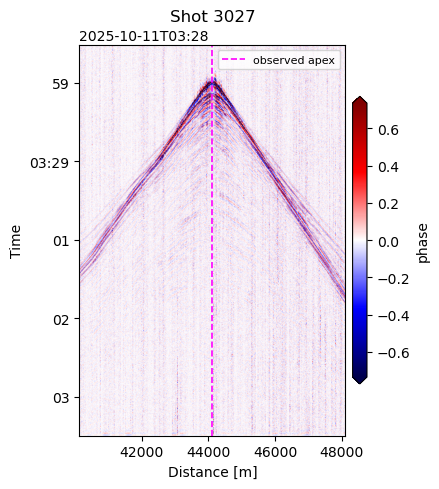

Cut starts 0.50 s before the apex and extends 6.00 s after it.


In [ ]:
pilot_index, pilot_cuts = process_recording(
    PILOT_RECORDING, shot_ids=PILOT_SHOT_IDS, write=WRITE_PILOT,
)
display(pilot_index)

ok = [sid for sid, patch in pilot_cuts.items()]
if not ok:
    raise RuntimeError('Pilot produced no cut gathers. Check status in pilot_index.')

n_show = min(4, len(ok))
fig, axes = plt.subplots(1, n_show, figsize=(4.5 * n_show, 5), squeeze=False)
for ax, sid in zip(axes[0], ok[:n_show]):
    patch = pilot_cuts[sid]
    row = pilot_index.loc[pilot_index['shot_id'] == sid].iloc[0]
    patch.viz.waterfall(ax=ax, scale=0.1, cmap='seismic')
    ax.axvline(row.obs_apex_s_m, color='magenta', ls='--', lw=1.2, label='observed apex')
    ax.set_title(f'Shot {sid}')
    ax.legend(loc='upper right', fontsize=10)
fig.tight_layout()
plt.show()

print(
    f'Cut starts {PRE_APEX_S:.2f} s before the apex and '
    f'extends {POST_APEX_S:.2f} s after it.'
)

## Batch processing

Writes one `shot_<id>.h5` per catalog shot and `shot_gather_index.csv` in `OUT_DIR`. 

In [ ]:
if not RUN_BATCH:
    print('RUN_BATCH is False. Set it to True in the parameter cell to process every recording.')
else:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    index_frames = []
    recordings = shots['recording_filename'].drop_duplicates().tolist()
    for i, name in enumerate(recordings, start=1):
        print(f'[{i}/{len(recordings)}] {name}')
        try:
            index_i, _ = process_recording(name, write=True)
        except FileNotFoundError as exc:
            print('  missing file:', exc)
            continue
        index_frames.append(index_i)
        pd.concat(index_frames, ignore_index=True).to_csv(OUT_DIR / 'shot_gather_index.csv', index=False)

    batch_index = pd.concat(index_frames, ignore_index=True)
    print(batch_index['status'].value_counts().to_string())
    print('Index:', OUT_DIR / 'shot_gather_index.csv')

,file,shape_time_distance,t0_utc,t1_utc,s0_m,s1_m
0,shot_03027.h5,"(998, 627)",2025-10-11T03:28:58.510028891,2025-10-11T03:29:03.495028891,40123.428429,48112.380781
1,shot_03059.h5,"(972, 313)",2025-10-11T03:32:42.640028891,2025-10-11T03:32:47.495028891,42535.428420,46517.142692
2,shot_03061.h5,"(965, 313)",2025-10-11T03:32:56.675028891,2025-10-11T03:33:01.495028891,42892.761752,46874.476024


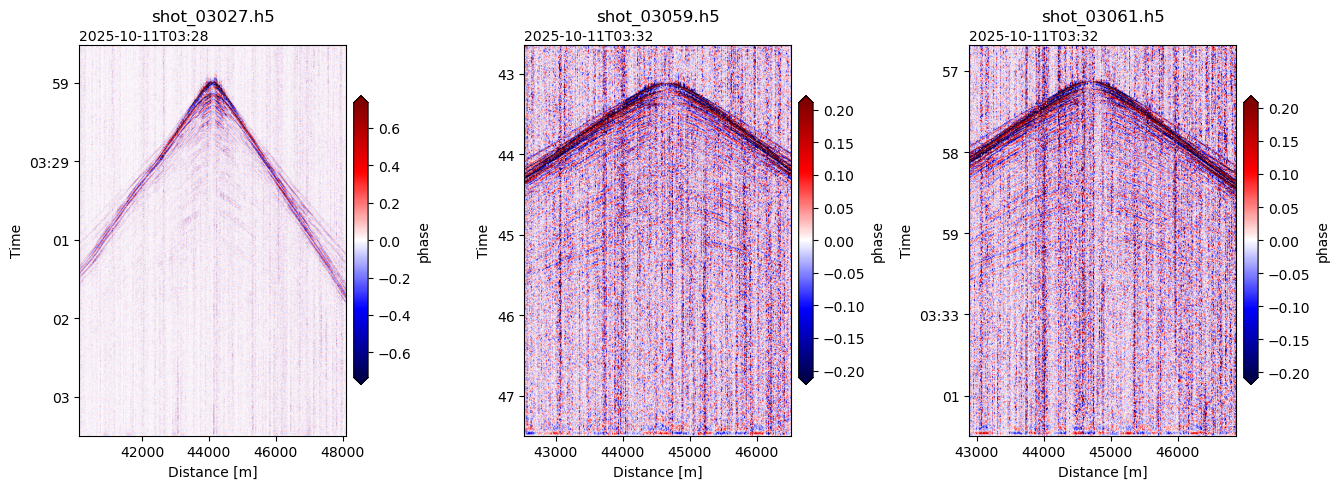

In [11]:
# Read a few saved shot gathers and show the cut window.
N_SAMPLES = 4
sample_paths = sorted(OUT_DIR.glob('shot_*.h5'))[:N_SAMPLES]
if not sample_paths:
    raise FileNotFoundError(f'No shot_*.h5 files in {OUT_DIR}')

sample_rows = []
sample_patches = []
for path in sample_paths:
    patch = dc.read(path, file_format='dasdae')[0]
    time_coord = np.asarray(patch.get_coord('time').values)
    dist = np.asarray(patch.get_coord('distance').values, dtype=float)
    sample_patches.append(patch)
    sample_rows.append({
        'file': path.name,
        'shape_time_distance': patch.data.shape,
        't0_utc': str(time_coord[0]),
        't1_utc': str(time_coord[-1]),
        's0_m': float(dist.min()),
        's1_m': float(dist.max()),
    })

sample_index = pd.DataFrame(sample_rows)
display(sample_index)

fig, axes = plt.subplots(1, len(sample_patches), figsize=(4.5 * len(sample_patches), 5), squeeze=False)
for ax, patch, row in zip(axes[0], sample_patches, sample_rows):
    patch.viz.waterfall(ax=ax, scale=0.1, cmap='seismic')
    ax.set_title(row['file'])
fig.tight_layout()
plt.show()
